In [1]:
# Do-Operator Assignment
# HI823 Causal AI
# Author: Abdul

# This notebook analyzes the causal impact of medication on remission
# using conditional probabilities and the do-operator.

In [2]:
!pip install networkx matplotlib pandas

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

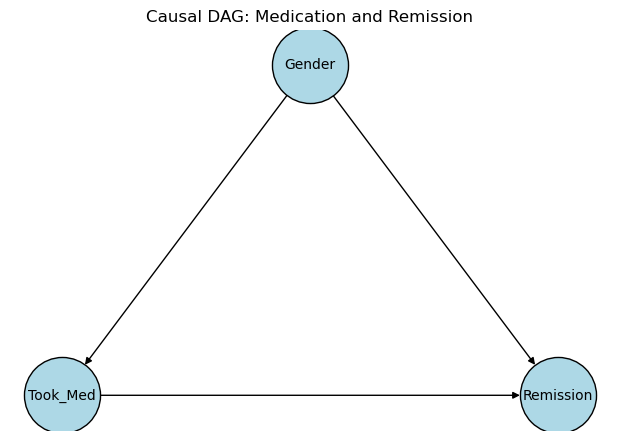

In [17]:
# Construct the DAG described in the assignment

G = nx.DiGraph()

G.add_edges_from([
    ("Gender", "Took_Med"),
    ("Gender", "Remission"),
    ("Took_Med", "Remission")
])

plt.figure(figsize=(6,4))

pos = {
    "Gender": (0,0.4),
    "Took_Med": (-0.3,0),
    "Remission": (0.3,0)
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    edgecolors="black",
    font_size=10,
    arrows=True
)

plt.title("Causal DAG: Medication and Remission")
plt.show()

In [6]:
#Create the dataset
data = {
    "Gender": ["Men","Men","Women","Women"],
    "Medication": ["Med","NoMed","Med","NoMed"],
    "Recovering": [81,234,192,55],
    "Total": [87,270,263,80]
}

df = pd.DataFrame(data)

df["Recovery_Rate"] = df["Recovering"] / df["Total"]

df

,Gender,Medication,Recovering,Total,Recovery_Rate
0,Men,Med,81,87,0.931034
1,Men,NoMed,234,270,0.866667
2,Women,Med,192,263,0.730038
3,Women,NoMed,55,80,0.687500


In [7]:
#Part (a) Prob of medication, Given Female
women_med = 263
women_total = 263 + 80

p_med_female = women_med / women_total

print("P(Med | Female) =", round(p_med_female,3))

P(Med | Female) = 0.767


In [8]:
#Part (b) Remission Given Female and Medication 
p_r_med_female = 192 / 263

print("P(Remission | Med, Female) =", round(p_r_med_female,3))

P(Remission | Med, Female) = 0.73


In [9]:
#Part (c) Remission Given Male and Medication
p_r_med_male = 81 / 87

print("P(Remission | Med, Male) =", round(p_r_med_male,3))

P(Remission | Med, Male) = 0.931


In [10]:
#Part (d) Identify Selection Bias Variable
print("Confounder:", "Gender")
# Gender affects both:
# - Medication choice
# - Remission outcome
# Therefore Gender is a confounder and causes selection bias if not adjusted.

Confounder: Gender


In [11]:
#Part (e) Compute Causal Effect Using Adjustment

# Population proportions

p_female = 343 / 700
p_male = 357 / 700

# Recovery rates (remissions) with medication

p_r_med_m = 81 / 87
p_r_med_f = 192 / 263

# Recovery rates (remissions) without medication

p_r_nom_m = 234 / 270
p_r_nom_f = 55 / 80

# do(Med)

p_do_med = (p_r_med_m * p_male) + (p_r_med_f * p_female)

# do(NoMed)

p_do_nom = (p_r_nom_m * p_male) + (p_r_nom_f * p_female)

ace = p_do_med - p_do_nom

print("P(R | do(Med)) =", round(p_do_med,3))
print("P(R | do(NoMed)) =", round(p_do_nom,3))
print("Average Causal Effect =", round(ace,3))

P(R | do(Med)) = 0.833
P(R | do(NoMed)) = 0.779
Average Causal Effect = 0.054


In [12]:
#interpretation
print("Medication increases remission probability by", round(ace*100,2), "percentage points")

Medication increases remission probability by 5.37 percentage points


# Key causal inference : take home lessons

# 1. Observational comparisons can be biased
# 2. Confounders must be adjusted
# 3. The do-operator estimates causal effects
# 4. Adjustment formula recovers causal probability